# Qiskit ile Kuantum Hesaplamaya Giriş

Bu notebook, kuantum hesaplamayı **ilk kez** öğrenenler için hazırlandı. Hiçbir ön bilgi gerekmiyor; her bölümde önce fikri, sonra küçük bir kod örneğini göreceğiz.

**İçindekiler**
1. Bit ve Qubit
2. İlk devremiz: X (NOT) kapısı
3. Süperpozisyon: Hadamard (H) kapısı
4. Durum vektörüne bakmak
5. Faz kapıları: Z, S ve T
6. İki qubit: CNOT kapısı
7. Dolanıklık: Bell durumu
8. Kontrollü-Z (CZ) kapısı
9. Üç qubit: Toffoli kapısı
10. Kuantum algoritmalarına kısa bakış
11. Özet ve alıştırmalar

## 0. Kurulum

Qiskit, IBM'in geliştirdiği açık kaynaklı bir kuantum programlama kütüphanesidir. Aşağıdaki hücreyi bir kez çalıştırmanız yeterli (Google Colab'da birkaç saniye sürer). `[visualization]` eki, devreleri görsel olarak çizebilmemiz için gereken paketleri de kurar.

In [1]:
!pip install -q "qiskit[visualization]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 50.5 MB/s eta 0:00:00


Bütün örneklerde kullanacağımız araçları içe aktaralım:

- `QuantumCircuit` → devreyi kurduğumuz yer
- `Statevector` → qubit'lerin **ölçümden önceki** durumunu görmemizi sağlar
- `StatevectorSampler` → devreyi bilgisayarımızda simüle edip **ölçüm sonuçlarını** verir

Kodları kısaltmak için iki küçük yardımcı fonksiyon da yazıyoruz:

- `calistir(devre, tekrar)` devreyi istediğimiz kadar çalıştırır ve hangi sonucun kaç kez çıktığını sayar.
- `ciz(devre)` devrenin **görsel** (renkli) halini çizer.
- `bloch_adimlari(devre)` qubit'in **Bloch küresi** üzerindeki yolculuğunu adım adım, küreleri yan yana çizerek gösterir (Bloch küresini 1. bölümde anlatıyoruz).

Her örnekte sırasıyla şunları göreceksiniz: metin (ASCII) çizim → görsel devre → Bloch küreleri → sonuçlar.

*Bu fonksiyonların içini anlamanız gerekmiyor; sadece kullanmanız yeterli.*

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import DensityMatrix, partial_trace, Pauli
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt

sampler = StatevectorSampler()

def calistir(devre, tekrar=1000):
    """Devreyi 'tekrar' kez çalıştırır, sonuçları sayar."""
    sonuc = sampler.run([devre], shots=tekrar).result()[0]
    return sonuc.data.c.get_counts()

def ciz(devre):
    """Devrenin görsel halini çizer."""
    display(devre.draw("mpl"))

def bloch_vektoru(durum, qubit):
    """Bir qubit'in Bloch küresindeki okunu [x, y, z] olarak hesaplar."""
    rho = DensityMatrix(durum)
    digerleri = [i for i in range(durum.num_qubits) if i != qubit]
    if digerleri:
        rho = partial_trace(rho, digerleri)
    return [round(float(rho.expectation_value(Pauli(p)).real), 6) + 0.0 for p in "XYZ"]

def bloch_adimlari(devre):
    """Devreyi kapı kapı ilerletir; her adımda her qubit'in Bloch küresini yan yana çizer."""
    n = devre.num_qubits
    durum = Statevector.from_label("0" * n)
    adimlar = [("Başlangıç", durum)]
    for komut in devre.data:
        kapi = komut.operation
        if kapi.name in ("measure", "barrier"):
            continue                       # ölçüm küre üzerinde gösterilmez
        qubitler = [devre.find_bit(q).index for q in komut.qubits]
        durum = durum.evolve(kapi, qargs=qubitler)
        etiket = kapi.name.upper() + " (" + ", ".join(f"q{i}" for i in qubitler) + ")"
        adimlar.append((f"{len(adimlar)}. {etiket}", durum))

    sutun = len(adimlar)
    fig = plt.figure(figsize=(2.6 * sutun, 2.9 * n))
    for q in range(n):
        for s, (baslik, d) in enumerate(adimlar):
            ax = fig.add_subplot(n, sutun, q * sutun + s + 1, projection="3d")
            plot_bloch_vector(bloch_vektoru(d, q), ax=ax, font_size=11)
            ax.set_title((f"q{q} · " if n > 1 else "") + baslik, fontsize=11, pad=22)
    fig.subplots_adjust(wspace=0.05, hspace=0.35)
    plt.show()

print("Hazırız!")

Hazırız!


## 1. Bit ve Qubit

Bildiğimiz bilgisayarlar **bit** ile çalışır. Bir bit ya **0** ya da **1**'dir; tıpkı ya açık ya kapalı olan bir lamba gibi.

Kuantum bilgisayarların temel birimi ise **qubit**'tir (kuantum biti). Qubit:

- $|0\rangle$ ya da $|1\rangle$ durumunda olabilir,
- ya da ikisinin bir **karışımında** (süperpozisyon) bulunabilir.

Ama dikkat: Bir qubit'i **ölçtüğümüzde** sonuç her zaman ya 0 ya da 1 çıkar. Süperpozisyon, sadece hangi sonucun hangi olasılıkla çıkacağını belirler.

### Gösterim

Qubit durumlarını $|\;\rangle$ ("ket") işaretiyle yazarız:

| Durum | Anlamı | Vektör |
| :--- | :--- | :--- |
| $|0\rangle$ | Kesinlikle 0 | $\begin{pmatrix} 1 \\ 0 \end{pmatrix}$ |
| $|1\rangle$ | Kesinlikle 1 | $\begin{pmatrix} 0 \\ 1 \end{pmatrix}$ |
| $\alpha|0\rangle + \beta|1\rangle$ | Süperpozisyon | $\begin{pmatrix} \alpha \\ \beta \end{pmatrix}$ |

$\alpha$ ve $\beta$ sayılarına **genlik** denir. Ölçümde **0** çıkma olasılığı $|\alpha|^2$, **1** çıkma olasılığı $|\beta|^2$'dir. Olasılıkların toplamı her zaman 1'dir: $|\alpha|^2 + |\beta|^2 = 1$.

### Bloch Küresi: Qubit'i Gözle Görmek

Tek bir qubit'in durumunu bir **küre üzerindeki ok** olarak çizebiliriz. Bu küreye **Bloch küresi** denir.

- **Kuzey kutbu** (yukarı) → $|0\rangle$
- **Güney kutbu** (aşağı) → $|1\rangle$
- **Ekvator** → 0 ile 1'in eşit karışımı (%50 – %50). Örneğin $|+\rangle$ durumu $x$ ekseninin ucunda, $|-\rangle$ ise tam karşısındadır.

Ok kuzeye ne kadar yakınsa 0 çıkma olasılığı o kadar yüksektir. Okun ekvator etrafındaki **yönü** ise **faz**dır.

**Kapılar = küre üzerinde döndürmeler.** Her kapı oku belirli bir eksen etrafında çevirir:

| Kapı | Küre üzerindeki etkisi |
| :--- | :--- |
| X | $x$ ekseni etrafında 180° |
| Z | $z$ ekseni etrafında 180° |
| S | $z$ ekseni etrafında 90° |
| T | $z$ ekseni etrafında 45° |
| H | $x$ ile $z$'nin tam ortasındaki eksen etrafında 180° |

Örneklerde `bloch_adimlari(...)` ile her kapıdan sonra okun nereye gittiğini yan yana kürelerde göreceğiz. Birden fazla qubit varsa, **her qubit için ayrı bir satır** çizilir.

## 2. İlk Devremiz: X (NOT) Kapısı

Bir **kuantum devresi** şu üç parçadan oluşur:

**Devre = Qubit'ler + Kapılar + Ölçüm**

**Kapılar**, qubit'in durumunu değiştiren işlemlerdir. En basiti **X kapısı**dır ve klasik NOT gibi çalışır:

$$X|0\rangle = |1\rangle \qquad X|1\rangle = |0\rangle \qquad X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

Qiskit'te her qubit **$|0\rangle$ durumunda başlar**. Ona X uygulayıp ölçelim:

     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


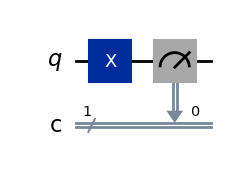

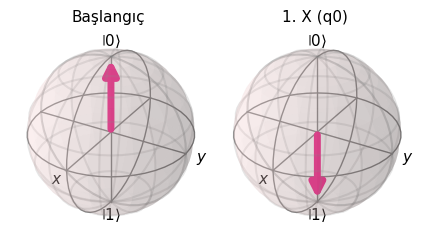

Sonuçlar: {'1': 100}


In [3]:
# 1 qubit ve ölçüm sonucunu yazmak için 1 klasik bit
qc = QuantumCircuit(1, 1)

qc.x(0)            # 0 numaralı qubit'e X kapısı
qc.measure(0, 0)   # qubit 0'ı ölç, sonucu klasik bit 0'a yaz

print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Sonuçlar:", calistir(qc, 100))

**Yorum:** 100 çalıştırmanın hepsinde `1` çıktı. Qubit $|0\rangle$'dan başladı, X onu $|1\rangle$'e çevirdi. Burada henüz "kuantum" bir şey yok; tamamen klasik NOT gibi davrandı.

**Küre üzerinde:** Ok kuzey kutbundan ($|0\rangle$) güney kutbuna ($|1\rangle$) döndü. (Ölçüm adımı kürede gösterilmez, çünkü ölçüm bir döndürme değildir.)

## 3. Süperpozisyon: Hadamard (H) Kapısı

Asıl ilginç kısım şimdi başlıyor. **Hadamard (H)** kapısı, $|0\rangle$ durumundaki qubit'i 0 ile 1'in **eşit karışımına** getirir:

$$H|0\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle \quad (\text{bu duruma } |+\rangle \text{ denir})$$

Her iki genlik de $\frac{1}{\sqrt{2}} \approx 0.707$ olduğu için olasılıklar $0.707^2 = 0.5$, yani **%50 – %50**.

Bunu bir yazı-turaya benzetebiliriz: Para havadayken ne yazı ne turadır; yere düştüğünde (ölçüldüğünde) ikisinden biri olur.

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


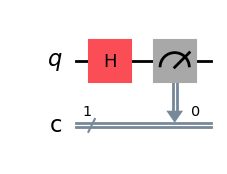

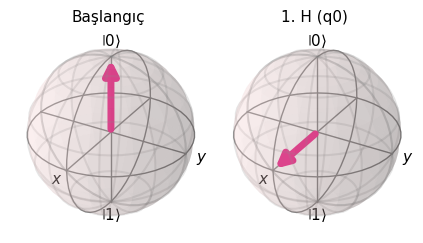

Sonuçlar: {'1': 500, '0': 500}


In [4]:
qc = QuantumCircuit(1, 1)
qc.h(0)            # Hadamard: süperpozisyon oluştur
qc.measure(0, 0)

print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Sonuçlar:", calistir(qc, 1000))

**Yorum:** 1000 denemede 0 ve 1 yaklaşık 500'er kez çıktı. Hücreyi tekrar çalıştırırsanız sayılar biraz değişir; bu, sonucun gerçekten **rastgele** olduğunu gösterir.

**Küre üzerinde:** H kapısı oku kuzey kutbundan **ekvatora**, $x$ ekseninin ucuna ($|+\rangle$) indirdi. Ok ekvatordayken kuzeye ve güneye eşit uzaklıkta olduğu için sonuç %50 – %50 çıkar.

## 4. Ölçümden Önce: Durum Vektörüne Bakmak

Gerçek bir kuantum bilgisayarda qubit'in içine bakamayız; sadece ölçüm sonuçlarını görürüz. Ama **simülasyonda** genlikleri doğrudan görebiliriz. Bunun için devreye **ölçüm eklemeden** `Statevector` kullanırız.

   ┌───┐
q: ┤ H ├
   └───┘


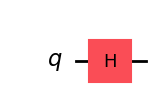

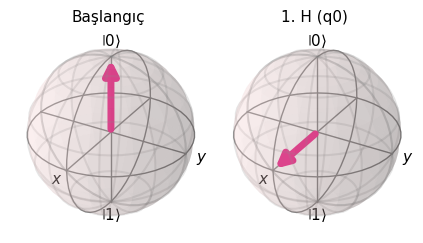

Genlikler [|0>, |1>]: [0.707+0.j 0.707+0.j]
Olasılıklar [0, 1]: [0.5 0.5]


In [5]:
qc = QuantumCircuit(1)   # ölçüm yok, klasik bite de gerek yok
qc.h(0)

durum = Statevector(qc)
print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Genlikler [|0>, |1>]:", durum.data.round(3))
print("Olasılıklar [0, 1]:", durum.probabilities().round(2))

**Yorum:** Genlikler `[0.707, 0.707]` çıktı, yani $\frac{1}{\sqrt{2}}$ ve $\frac{1}{\sqrt{2}}$. Olasılıklar da beklediğimiz gibi %50 – %50.

> İpucu: Bundan sonra **ölçüm sonuçları** için `calistir(...)`, **genlikler** için `Statevector(...)` kullanacağız.

## 5. Faz Kapıları: Z, S ve T

Genlikler sadece pozitif sayılar değildir; **eksi** veya **karmaşık** sayı da olabilirler. Genliğin bu "yönüne" **faz** denir.

Faz, tek başına ölçüm olasılıklarını değiştirmez ama başka kapılarla birleşince sonucu değiştirebilir. Kuantum algoritmalarının gücü büyük ölçüde fazdan gelir.

| Kapı | $|1\rangle$'e ne yapar? | Matris |
| :--- | :--- | :--- |
| **Z** | $-1$ ile çarpar | $\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ |
| **S** | $i$ ile çarpar | $\begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}$ |
| **T** | $e^{i\pi/4}$ ile çarpar | $\begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$ |

Üçü de $|0\rangle$'ı hiç değiştirmez. (Aralarındaki ilişki: $T \cdot T = S$, $S \cdot S = Z$.)

### Z kapısı

$|+\rangle$ durumuna Z uygularsak $|1\rangle$'in genliği eksi olur:
$$Z|+\rangle = \frac{1}{\sqrt{2}}|0\rangle - \frac{1}{\sqrt{2}}|1\rangle \quad (\text{bu duruma } |-\rangle \text{ denir})$$

   ┌───┐┌───┐
q: ┤ H ├┤ Z ├
   └───┘└───┘


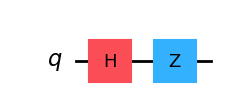

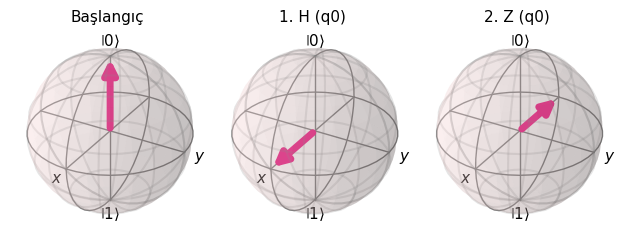

Genlikler: [ 0.707+0.j -0.707+0.j]
Olasılıklar [0, 1]: [0.5 0.5]


In [6]:
qc = QuantumCircuit(1)
qc.h(0)   # |+>
qc.z(0)   # |1> genliğinin işaretini çevir

durum = Statevector(qc)
print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Genlikler:", durum.data.round(3))
print("Olasılıklar [0, 1]:", durum.probabilities().round(2))

**Yorum:** İkinci genlik **eksi** oldu ($-0.707$), ama olasılıklar hâlâ %50 – %50. Yani sadece ölçerek $|+\rangle$ ile $|-\rangle$'yi ayırt edemeyiz.

**Küre üzerinde:** Z kapısı oku ekvator üzerinde 180° döndürdü: $+x$ yönünden $-x$ yönüne. Ok hâlâ ekvatorda olduğu için olasılıklar değişmedi; değişen sadece yön, yani **faz**.

### Fazın neden önemli olduğunu görelim

$|+\rangle$ ile $|-\rangle$ ölçümde aynı görünür. Ama ikisine de **bir kez daha H** uygularsak sonuçlar tamamen farklılaşır:

Devre A (H, H):


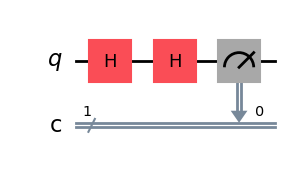

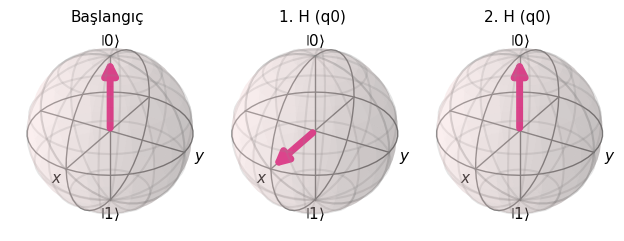

Devre B (H, Z, H):


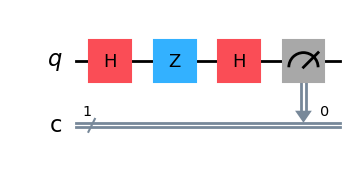

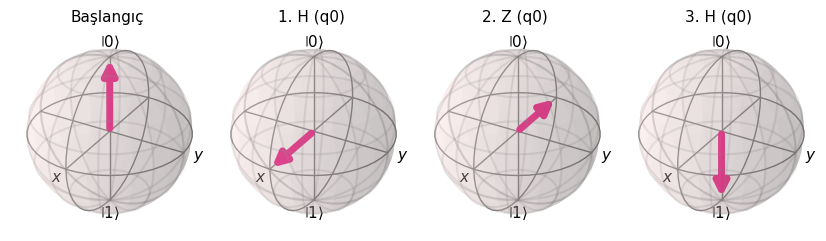

H, H     : {'0': 1000}
H, Z, H  : {'1': 1000}


In [7]:
# Devre A: H -> H
a = QuantumCircuit(1, 1)
a.h(0); a.h(0)
a.measure(0, 0)

# Devre B: H -> Z -> H
b = QuantumCircuit(1, 1)
b.h(0); b.z(0); b.h(0)
b.measure(0, 0)

print("Devre A (H, H):")
ciz(a)
bloch_adimlari(a)
print("Devre B (H, Z, H):")
ciz(b)
bloch_adimlari(b)

print("H, H     :", calistir(a))
print("H, Z, H  :", calistir(b))

**Yorum:** Arada Z olmayan devre her zaman **0**, Z olan devre her zaman **1** verdi. Gözle göremediğimiz faz farkı, H kapısı sayesinde ölçülebilir bir farka dönüştü. Buna **girişim** (interference) denir.

**Küre üzerinde:** Devre A'da ikinci H oku geri kuzeye ($|0\rangle$) götürür. Devre B'de ise Z oku ekvatorda $-x$'e çevirdiği için ikinci H onu **güneye** ($|1\rangle$) götürür.

### S ve T kapıları

S ve T, Z'nin "daha küçük adımlı" versiyonlarıdır. $|1\rangle$'e uygulayıp genliğe bakalım:

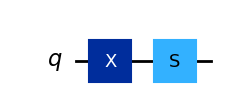

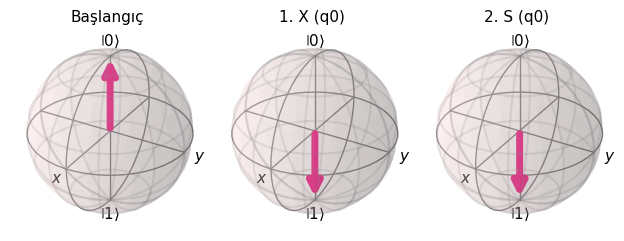

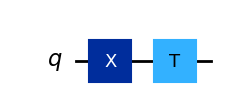

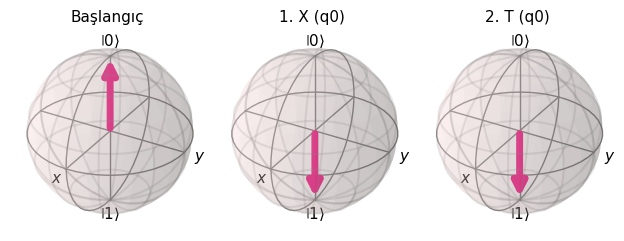

S|1> genlikleri: [0.+0.j 0.+1.j]
T|1> genlikleri: [0.   +0.j    0.707+0.707j]


In [8]:
qc_s = QuantumCircuit(1)
qc_s.x(0)   # |1>
qc_s.s(0)

qc_t = QuantumCircuit(1)
qc_t.x(0)   # |1>
qc_t.t(0)

ciz(qc_s)
bloch_adimlari(qc_s)
ciz(qc_t)
bloch_adimlari(qc_t)
print("S|1> genlikleri:", Statevector(qc_s).data.round(3))
print("T|1> genlikleri:", Statevector(qc_t).data.round(3))

**Yorum:**
- S sonrası $|1\rangle$'in genliği $1j$ oldu (Python'da $i$ sayısı `j` ile yazılır).
- T sonrası genlik $0.707 + 0.707j$ oldu; bu, $e^{i\pi/4} = \cos 45° + i \sin 45°$ sayısıdır.

**Küre üzerinde:** $|1\rangle$ güney kutbunda olduğu için S ve T okun yerini **değiştirmez**; faz farkı tek bir qubit'te kutuplarda görünmez. Etkiyi görmek için alıştırma 5'i deneyin.

T kapısı, H gibi kapılarla birlikte kullanıldığında **her** kuantum işlemini yaklaşık olarak kurmaya yeter; bu yüzden çok önemlidir.

## 6. İki Qubit: CNOT Kapısı

İki qubit'le dört temel durum vardır: $|00\rangle, |01\rangle, |10\rangle, |11\rangle$.

**CNOT (Kontrollü-NOT)** kapısı iki qubit üzerinde çalışır:
- **Kontrol** qubit'i **0** ise → hedefe dokunmaz.
- **Kontrol** qubit'i **1** ise → hedefe **X (NOT)** uygular.

| Giriş (kontrol, hedef) | Çıkış |
| :---: | :---: |
| 0, 0 | 0, 0 |
| 0, 1 | 0, 1 |
| 1, 0 | 1, **1** |
| 1, 1 | 1, **0** |

> ⚠️ **Qiskit'te sonuçların okunuşu:** Qiskit, sonuçları **sağdan sola** yazar. `'10'` sonucu "qubit 1 = 1, qubit 0 = 0" demektir. Yani **en sağdaki rakam qubit 0'dır**. Başta kafa karıştırabilir; örneklerde hep belirteceğiz.

Kontrol = 1, hedef = 0 ile başlayalım:

     ┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


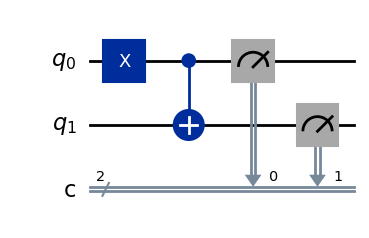

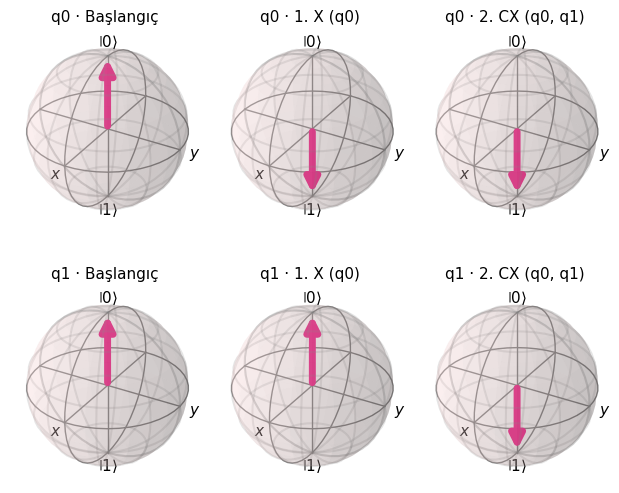

Sonuçlar: {'11': 100}


In [9]:
qc = QuantumCircuit(2, 2)
qc.x(0)          # kontrol qubit'i (q0) 1 yap
qc.cx(0, 1)      # CNOT: kontrol = q0, hedef = q1
qc.measure([0, 1], [0, 1])

print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Sonuçlar:", calistir(qc, 100))

**Yorum:** Sonuç `'11'`: kontrol 1 olduğu için hedef 0'dan 1'e döndü.

Kendiniz deneyin: `qc.x(0)` satırını silin. Kontrol 0 olacağı için hedef değişmez ve sonuç `'00'` çıkar.

**Küreler üzerinde:** Üst satır kontrol qubit'i (q0), alt satır hedef qubit'idir (q1). X sonrası q0 güneye döner; CNOT adımında q0 1 olduğu için q1 de güneye döner.

Bütün girişleri tek seferde test edelim:

In [16]:
for kontrol in [0, 1]:
    for hedef in [0, 1]:
        qc = QuantumCircuit(2, 2)
        if kontrol: qc.x(0)
        if hedef:   qc.x(1)
        qc.cx(0, 1)
        qc.measure([0, 1], [0, 1])

        sonuc = list(calistir(qc, 10))[0]       # örn. '11'
        yeni_hedef, yeni_kontrol = sonuc[0], sonuc[1]  # sağdan sola!
        print(f"Giriş (kontrol={kontrol}, hedef={hedef})  ->  "
              f"Çıkış (kontrol={yeni_kontrol}, hedef={yeni_hedef})")

Giriş (kontrol=0, hedef=0)  ->  Çıkış (kontrol=0, hedef=0)
Giriş (kontrol=0, hedef=1)  ->  Çıkış (kontrol=0, hedef=1)
Giriş (kontrol=1, hedef=0)  ->  Çıkış (kontrol=1, hedef=1)
Giriş (kontrol=1, hedef=1)  ->  Çıkış (kontrol=1, hedef=0)


## 7. Dolanıklık: Bell Durumu

Şimdi H ve CNOT'u birleştirelim:
1. Qubit 0'a **H** → %50 ihtimalle 0, %50 ihtimalle 1
2. **CNOT(0 → 1)** → qubit 0 ne ise qubit 1 de o olur

Sonuçta şu durum oluşur (**Bell durumu**):
$$\frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right)$$

Bu iki qubit artık **dolanık**tır: Tek tek her biri rastgele davranır, ama ikisinin sonucu **her zaman aynı** çıkar.

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


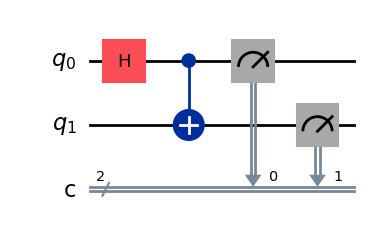

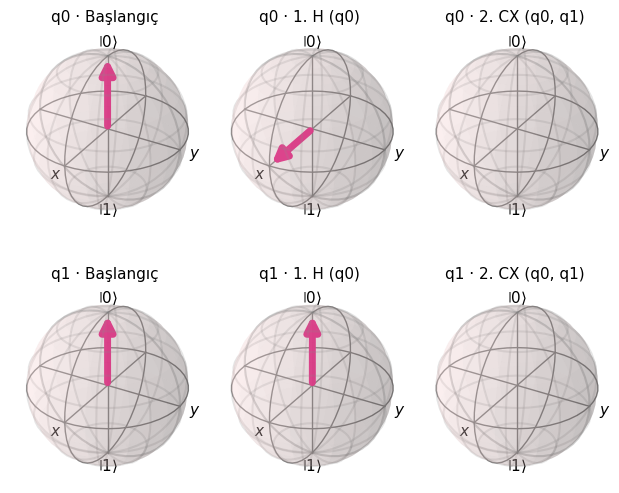

Sonuçlar: {'00': 486, '11': 514}


In [11]:
qc = QuantumCircuit(2, 2)
qc.h(0)          # süperpozisyon
qc.cx(0, 1)      # dolanıklık
qc.measure([0, 1], [0, 1])

print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Sonuçlar:", calistir(qc, 1000))

**Yorum:** Sadece `'00'` ve `'11'` çıktı, yaklaşık yarı yarıya. `'01'` veya `'10'` **hiç** çıkmadı.

**Önemli bir not:** Dolanıklık bazen "anında haberleşme" gibi anlatılır, ama bu doğru değil. Qubit'ler arasında mesaj gitmez; sadece sonuçları birbirine **bağlıdır**. Bu bağlantıyı ancak iki tarafın sonuçlarını sonradan karşılaştırınca görebiliriz.

**Küreler üzerinde ilginç bir şey:** CNOT adımından sonra iki qubit'in de oku **kayboldu** (kürenin merkezine çöktü). Bu bir hata değil! Dolanık bir qubit'in **tek başına** belirli bir yönü yoktur; bilginin tamamı iki qubit'in **ilişkisinde** saklıdır. Bloch küresi tek bir qubit'i gösterdiği için bu ilişkiyi çizemez. Okun kaybolması, dolanıklığın görsel bir işaretidir.

## 8. Kontrollü-Z (CZ) Kapısı

**CZ** kapısı, ancak **iki qubit de 1** ise $|11\rangle$ durumunun genliğini $-1$ ile çarpar. Diğer durumlara dokunmaz.

$$CZ = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{pmatrix}$$

İlginç bir özelliği: CNOT'tan farklı olarak **simetriktir**. Hangi qubit'in "kontrol" olduğunun önemi yoktur.

İki qubit'i de $|+\rangle$ yapıp CZ uygulayalım:

     ┌───┐   
q_0: ┤ H ├─■─
     ├───┤ │ 
q_1: ┤ H ├─■─
     └───┘   


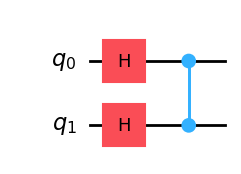

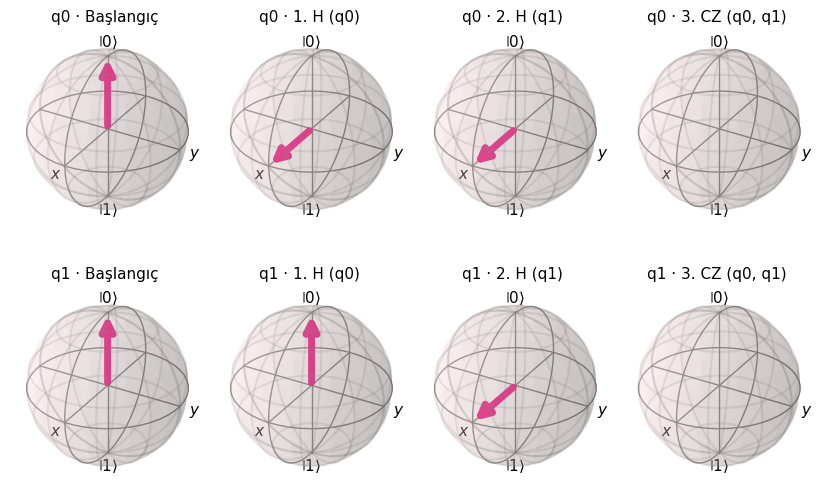

Genlikler:
  |00> : +0.50
  |01> : +0.50
  |10> : +0.50
  |11> : -0.50


In [12]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.cz(0, 1)

durum = Statevector(qc)
print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Genlikler:")
for etiket, genlik in zip(["00", "01", "10", "11"], durum.data):
    print(f"  |{etiket}> : {genlik.real:+.2f}")

**Yorum:** Dört genlik de $0.5$ büyüklüğünde, ama sadece $|11\rangle$'inki **eksi**. Ölçüm olasılıkları yine eşittir (%25'er), fark yalnızca fazdadır. Bu küçük işaret farkı bile iki qubit'i dolanık hale getirmeye yeter.

**Küreler üzerinde:** Bell durumunda olduğu gibi CZ adımından sonra okların ikisi de kayboldu. Bu, CZ'nin de qubit'leri **dolanık** hale getirdiğini gösterir.

## 9. Üç Qubit: Toffoli (CCX) Kapısı

**Toffoli** kapısının **iki kontrol** ve **bir hedef** qubit'i vardır:
- İki kontrol de **1** ise → hedefe X uygular.
- Diğer bütün durumlarda → hiçbir şey yapmaz.

Klasik **VE (AND)** işlemine benzer: hedef 0'dan başlarsa, sonuçta hedef = kontrol1 **VE** kontrol2 olur.

Önce iki kontrolü de 1 yapalım:

     ┌───┐     ┌─┐      
q_0: ┤ X ├──■──┤M├──────
     ├───┤  │  └╥┘┌─┐   
q_1: ┤ X ├──■───╫─┤M├───
     └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ─────┤ X ├─╫──╫─┤M├
          └───┘ ║  ║ └╥┘
c: 3/═══════════╩══╩══╩═
                0  1  2 


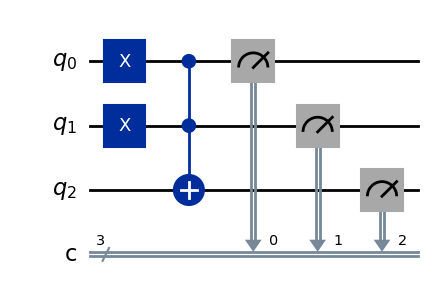

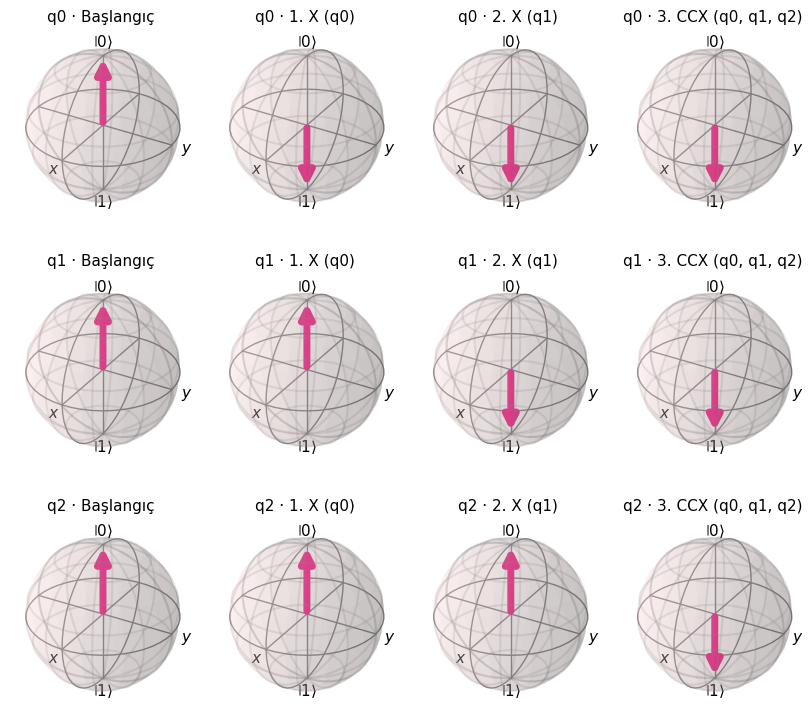

Sonuçlar: {'111': 100}


In [13]:
qc = QuantumCircuit(3, 3)
qc.x(0)              # kontrol 1 = 1
qc.x(1)              # kontrol 2 = 1
qc.ccx(0, 1, 2)      # Toffoli: kontroller q0, q1 -> hedef q2
qc.measure([0, 1, 2], [0, 1, 2])

print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print("Sonuçlar:", calistir(qc, 100))

**Yorum:** Sonuç `'111'`: iki kontrol de 1 olduğu için hedef 0'dan 1'e döndü.

**Küreler üzerinde:** Satırlar q0, q1 ve q2'yi gösterir. İlk iki adımda kontroller güneye döner; CCX adımında ise hedef (q2) de güneye döner.

Şimdi bütün kontrol kombinasyonlarını deneyelim ve Toffoli'nin bir **VE kapısı** gibi çalıştığını görelim:

In [14]:
print("k1  k2  ->  hedef")
for k1 in [0, 1]:
    for k2 in [0, 1]:
        qc = QuantumCircuit(3, 3)
        if k1: qc.x(0)
        if k2: qc.x(1)
        qc.ccx(0, 1, 2)
        qc.measure([0, 1, 2], [0, 1, 2])

        sonuc = list(calistir(qc, 10))[0]   # örn. '111'
        hedef = sonuc[0]                    # en soldaki rakam = qubit 2
        print(f" {k1}   {k2}  ->    {hedef}")

k1  k2  ->  hedef
 0   0  ->    0
 0   1  ->    0
 1   0  ->    0
 1   1  ->    1


**Yorum:** Hedef yalnızca `1, 1` girişinde 1 oldu. Toffoli kapısı ile her klasik hesaplama (VE, DEĞİL vb.) kuantum devresi içinde yapılabilir.

## 10. Kuantum Algoritmalarına Kısa Bakış

Öğrendiğimiz kapılar, ünlü kuantum algoritmalarının yapı taşlarıdır:

- **Grover Algoritması (Arama):** Sırasız bir listede aradığımızı bulmak için klasik olarak yaklaşık $N$ adım gerekirken, Grover yaklaşık $\sqrt{N}$ adımda bulur. Örneğin 1.000.000 eleman için ~1.000 adım.
- **Shor Algoritması (Çarpanlara Ayırma):** Büyük sayıları asal çarpanlarına çok hızlı ayırabilir. Bugünkü internet şifrelemesinin (RSA) önemli bir kısmı bu işin zor olmasına dayandığı için, yeterince büyük bir kuantum bilgisayar bu şifreleri kırabilir.
- **Kuantum Fourier Dönüşümü (QFT):** Shor dahil birçok algoritmanın içinde kullanılan, **faz** bilgisi üzerinde çalışan bir işlemdir. 5. bölümde gördüğümüz faz kapıları burada kilit rol oynar.

## 11. Özet

| Kapı | Qiskit | Ne yapar? |
| :--- | :--- | :--- |
| X | `qc.x(q)` | 0 ↔ 1 çevirir (NOT) |
| H | `qc.h(q)` | Süperpozisyon oluşturur |
| Z | `qc.z(q)` | $|1\rangle$'in işaretini çevirir |
| S | `qc.s(q)` | $|1\rangle$'i $i$ ile çarpar |
| T | `qc.t(q)` | $|1\rangle$'i $e^{i\pi/4}$ ile çarpar |
| CNOT | `qc.cx(k, h)` | Kontrol 1 ise hedefe X |
| CZ | `qc.cz(a, b)` | İkisi de 1 ise işaret çevirir |
| Toffoli | `qc.ccx(k1, k2, h)` | İki kontrol de 1 ise hedefe X |

**Hatırlanacaklar**
- Qubit'ler $|0\rangle$'dan başlar.
- Ölçüm sonucu her zaman 0 veya 1'dir; süperpozisyon sadece olasılıkları belirler.
- Qiskit sonuçları **sağdan sola** yazar (en sağdaki rakam = qubit 0).
- `Statevector` → genlikleri görmek için, `calistir` → ölçüm sonuçları için.

### Alıştırmalar

1. Bir qubit'e **iki kez X** uygulayın. Sonuç ne olur? Neden?
2. $|1\rangle$ durumundan başlayıp H uygulayın (`qc.x(0)` sonra `qc.h(0)`). Genliklere `Statevector` ile bakın. $|+\rangle$'den farkı nedir?
3. Bell devresinde CNOT'tan sonra qubit 1'e **X** ekleyin. Hangi sonuçlar çıkıyor?
4. Bir qubit'e **iki kez T** uygulayın ve sonucu tek bir **S** ile karşılaştırın.
5. $|+\rangle$ durumundan başlayıp (`qc.h(0)`) art arda **T** kapıları ekleyin. Bloch kürelerinde okun ekvator üzerinde her adımda 45° döndüğünü görün. Kaç T sonra başa dönersiniz?

     ┌─┐
  q: ┤M├
     └╥┘
c: 1/═╩═
      0 


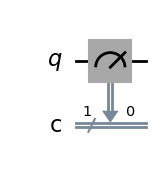

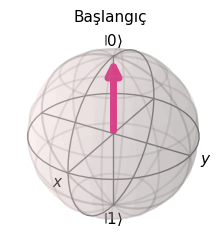

{'0': 1000}


In [15]:
# Alıştırmalarınızı burada deneyin
qc = QuantumCircuit(1, 1)

# kapılarınızı buraya ekleyin

qc.measure(0, 0)
print(qc.draw())
ciz(qc)
bloch_adimlari(qc)
print(calistir(qc))